<a href="https://www.kaggle.com/code/izzarsulynashrudin/classificationnihchestxrays?scriptVersionId=301123565" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Overview Project


Project ini menggunakan **NIH Chest X-Rays Dataset** untuk klasifikasi penyakit thoraks dan deteksi objek penyakit pada citra X-ray dada. Dataset ini berisi **112.120 gambar** sehingga sangat cocok untuk penelitian berbasis *deep learning* dalam tugas klasifikasi multi-label maupun object detection.

## Metode yang Digunakan


| Metode | Tugas                      | Metric Utama     |
| ------ | -------------------------- | ---------------- |
| CNN    | Multi-label classification | PR-AUC / ROC-AUC |
| ResNet | Multi-label classification | PR-AUC / ROC-AUC |
| YOLO   | Object detection           | mAP@0.5          |

## Link Download Dataset

[Situs Resmi](https://nihcc.app.box.com/v/ChestXray-NIHCC) 
atau 
[Kaggle Dataset](https://www.kaggle.com/datasets/nih-chest-xrays/data)

## Alasan Menggunakan Kaggle

Penggunaan Kaggle bertujuan untuk membantu proses pelatihan model karena dataset yang digunakan memiliki ukuran yang cukup besar, yaitu sebanyak **112.120 gambar**, sehingga membutuhkan akselerator GPU untuk meningkatkan performa model. Selain itu, proses pelatihan dan pengujian model juga memerlukan waktu yang cukup lama, sehingga Kaggle menjadi salah satu platform yang mendukung kebutuhan komputasi tersebut.

Oleh karena itu, saya mengucapkan terima kasih kepada pihak-pihak yang telah membantu dalam penelitian ini.

**Izzar Suly Nashrudin**


# Instalisasi Package

In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
logging.getLogger("absl").setLevel(logging.ERROR)

import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

import tensorflow as tf
tf.get_logger().setLevel("ERROR")

from tensorflow import keras
from tensorflow.keras import layers

2026-03-03 05:58:50.572184: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772517530.968903      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772517531.084697      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772517532.037715      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772517532.037782      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772517532.037789      24 computation_placer.cc:177] computation placer alr

# Preprocessing

## Set Path Dataset

In [2]:
datasetPath = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"
bboxPath = "/kaggle/input/datasets/organizations/nih-chest-xrays/data/BBox_List_2017.csv"

print(os.listdir(datasetPath)[:20])

['images_003', 'images_012', 'LOG_CHESTXRAY.pdf', 'README_CHESTXRAY.pdf', 'BBox_List_2017.csv', 'images_009', 'images_008', 'images_007', 'test_list.txt', 'images_010', 'ARXIV_V5_CHESTXRAY.pdf', 'images_002', 'images_011', 'Data_Entry_2017.csv', 'images_001', 'train_val_list.txt', 'images_005', 'FAQ_CHESTXRAY.pdf', 'images_004', 'images_006']


## Load dan Bersihkan Data Label

In [3]:
labelDf = pd.read_csv(os.path.join(datasetPath, "Data_Entry_2017.csv"))

labelDf = labelDf.loc[:, ~labelDf.columns.str.contains("^Unnamed")]

labelDf = labelDf.rename(columns={
    "Image Index": "imageIndex",
    "Finding Labels": "findingLabels",
    "Follow-up #": "followUpNumber",
    "Patient ID": "patientId",
    "Patient Age": "patientAge",
    "Patient Gender": "patientGender",
    "View Position": "viewPosition",
    "OriginalImage[Width": "originalImageWidth",
    "Height]": "originalImageHeight",
    "OriginalImagePixelSpacing[x": "originalImagePixelSpacingX",
    "y]": "originalImagePixelSpacingY"
})

labelDf.head()

,imageIndex,findingLabels,followUpNumber,patientId,patientAge,patientGender,viewPosition,originalImageWidth,originalImageHeight,originalImagePixelSpacingX,originalImagePixelSpacingY
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143


## Rapikan Tipe Data

In [4]:
numericColumns = [
    "followUpNumber",
    "patientId",
    "patientAge",
    "originalImageWidth",
    "originalImageHeight",
    "originalImagePixelSpacingX",
    "originalImagePixelSpacingY"
]

for columnName in numericColumns:
    labelDf[columnName] = pd.to_numeric(labelDf[columnName], errors="coerce")

labelDf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   imageIndex                  112120 non-null  object 
 1   findingLabels               112120 non-null  object 
 2   followUpNumber              112120 non-null  int64  
 3   patientId                   112120 non-null  int64  
 4   patientAge                  112120 non-null  int64  
 5   patientGender               112120 non-null  object 
 6   viewPosition                112120 non-null  object 
 7   originalImageWidth          112120 non-null  int64  
 8   originalImageHeight         112120 non-null  int64  
 9   originalImagePixelSpacingX  112120 non-null  float64
 10  originalImagePixelSpacingY  112120 non-null  float64
dtypes: float64(2), int64(5), object(4)
memory usage: 9.4+ MB


## Buat Label List dan Target Labels

In [5]:
labelDf["labelList"] = labelDf["findingLabels"].str.split("|")

allLabels = sorted({
    labelName
    for labelList in labelDf["labelList"]
    for labelName in labelList
})

targetLabels = sorted([
    labelName
    for labelName in allLabels
    if labelName != "No Finding"
])

print(targetLabels)
print("Total target labels:", len(targetLabels))

['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']
Total target labels: 14


## Multi-Label Encoding

In [6]:
for labelName in targetLabels:
    labelDf[labelName] = labelDf["labelList"].apply(
        lambda currentLabels: int(labelName in currentLabels)
    )

labelDf["noFinding"] = labelDf["findingLabels"].apply(
    lambda x: 1 if x == "No Finding" else 0
)

labelDf.head()

,imageIndex,findingLabels,followUpNumber,patientId,patientAge,patientGender,viewPosition,originalImageWidth,originalImageHeight,originalImagePixelSpacingX,...,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,noFinding
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,...,0,0,0,0,0,0,0,0,0,0
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,...,1,0,0,0,0,0,0,0,0,0
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,...,0,0,0,0,0,0,0,0,0,0
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,...,0,0,0,0,0,0,0,0,0,1
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,...,0,0,1,0,0,0,0,0,0,0


In [7]:
labelDf["labelList"]

0                    [Cardiomegaly]
1         [Cardiomegaly, Emphysema]
2          [Cardiomegaly, Effusion]
3                      [No Finding]
4                          [Hernia]
                    ...            
112115            [Mass, Pneumonia]
112116                 [No Finding]
112117                 [No Finding]
112118                 [No Finding]
112119                 [No Finding]
Name: labelList, Length: 112120, dtype: object

## Kumpulkan Semua Path Gambar

In [8]:
imageFolderPaths = []

for folderName in os.listdir(datasetPath):
    if folderName.startswith("images_"):
        folderPath = os.path.join(datasetPath, folderName, "images")
        if os.path.isdir(folderPath):
            imageFolderPaths.append(folderPath)

imageFolderPaths = sorted(imageFolderPaths)
print(imageFolderPaths)

['/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_001/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_002/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_004/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_005/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_006/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_007/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_008/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_009/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_010/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_011/images', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_012/images']


## Buat DataFrame Path Gambar

In [9]:
imageRows = []

for folderPath in imageFolderPaths:
    for imageName in os.listdir(folderPath):
        imageRows.append({
            "imageIndex": imageName,
            "imagePath": os.path.join(folderPath, imageName)
        })

imagePathDf = pd.DataFrame(imageRows)

print(imagePathDf.shape)
imagePathDf.head()

(112120, 2)


,imageIndex,imagePath
0,00000502_003.png,/kaggle/input/datasets/organizations/nih-chest...
1,00001255_008.png,/kaggle/input/datasets/organizations/nih-chest...
2,00001304_001.png,/kaggle/input/datasets/organizations/nih-chest...
3,00000003_003.png,/kaggle/input/datasets/organizations/nih-chest...
4,00000926_002.png,/kaggle/input/datasets/organizations/nih-chest...


## Merge Label + Path

In [10]:
masterDf = labelDf.merge(imagePathDf, on="imageIndex", how="left")
masterDf = masterDf.dropna(subset=["imagePath"]).reset_index(drop=True)

print(masterDf.shape)
print("Missing imagePath:", masterDf["imagePath"].isna().sum())
masterDf.head()

(112120, 28)
Missing imagePath: 0


,imageIndex,findingLabels,followUpNumber,patientId,patientAge,patientGender,viewPosition,originalImageWidth,originalImageHeight,originalImagePixelSpacingX,...,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,noFinding,imagePath
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,...,0,0,0,0,0,0,0,0,0,/kaggle/input/datasets/organizations/nih-chest...
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,...,0,0,0,0,0,0,0,0,0,/kaggle/input/datasets/organizations/nih-chest...
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,...,0,0,0,0,0,0,0,0,0,/kaggle/input/datasets/organizations/nih-chest...
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,...,0,0,0,0,0,0,0,0,1,/kaggle/input/datasets/organizations/nih-chest...
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,...,0,1,0,0,0,0,0,0,0,/kaggle/input/datasets/organizations/nih-chest...


## EDA Singkat

In [11]:
print("Total images:", len(masterDf))
print("Total patients:", masterDf["patientId"].nunique())

labelCounts = masterDf[targetLabels].sum().sort_values(ascending=False)
print(labelCounts)

Total images: 112120
Total patients: 30805
Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6331
Mass                   5782
Pneumothorax           5302
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2776
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1431
Hernia                  227
dtype: int64


Plot overview dataset

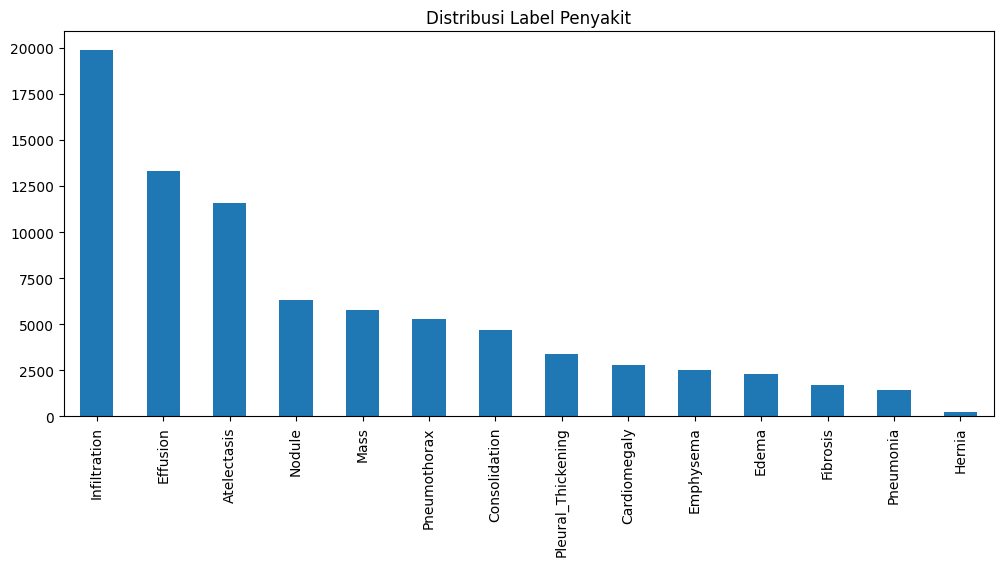

In [12]:
labelCounts.plot(kind="bar", figsize=(12, 5))
plt.title("Distribusi Label Penyakit")
plt.show()

# Training

## Split Data Patient-Wise

In [13]:
patientIds = masterDf["patientId"].dropna().unique()

trainPatients, tempPatients = train_test_split(
    patientIds,
    test_size=0.30,
    random_state=42
)

validPatients, testPatients = train_test_split(
    tempPatients,
    test_size=0.50,
    random_state=42
)

trainDf = masterDf[masterDf["patientId"].isin(trainPatients)].reset_index(drop=True)
validDf = masterDf[masterDf["patientId"].isin(validPatients)].reset_index(drop=True)
testDf = masterDf[masterDf["patientId"].isin(testPatients)].reset_index(drop=True)

print("Train shape:", trainDf.shape)
print("Valid shape:", validDf.shape)
print("Test shape:", testDf.shape)

Train shape: (78566, 28)
Valid shape: (17063, 28)
Test shape: (16491, 28)


## Siapkan Dataset TensorFlow

Gunakan ACCELERATOR untuk akses GPU dan CUDA

In [ ]:
imageSize = (224, 224)
batchSize = 32
autoTune = tf.data.AUTOTUNE

def decodeImage(imagePath):
    imageBytes = tf.io.read_file(imagePath)
    image = tf.io.decode_image(imageBytes, channels=1, expand_animations=False)
    image = tf.image.resize(image, imageSize)
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.grayscale_to_rgb(image)
    image.set_shape([imageSize[0], imageSize[1], 3])
    return image

def makeDataset(dataDf, shuffle=True):
    xPaths = dataDf["imagePath"].values
    yLabels = dataDf[targetLabels].values.astype(np.float32)

    ds = tf.data.Dataset.from_tensor_slices((xPaths, yLabels))

    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(dataDf), 10000), reshuffle_each_iteration=True)

    def mapFn(path, y):
        x = decodeImage(path)
        return x, y

    ds = ds.map(mapFn, num_parallel_calls=autoTune)
    ds = ds.batch(batchSize).prefetch(autoTune)
    return ds

trainDs = makeDataset(trainDf, shuffle=True)
validDs = makeDataset(validDf, shuffle=False)
testDs = makeDataset(testDf, shuffle=False)

print(trainDs)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 14), dtype=tf.float32, name=None))>


I0000 00:00:1772517568.297203      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772517568.303097      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# Model Convolutional Neural Network (CNN)

In [ ]:
numClasses = len(targetLabels)

cnnModel = keras.Sequential([
    layers.Input(shape=(imageSize[0], imageSize[1], 3)),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPool2D(),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPool2D(),
    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.MaxPool2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(numClasses, activation="sigmoid")
])

cnnModel.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="binaryAccuracy", threshold=0.5),
        keras.metrics.AUC(name="rocAuc"),
        keras.metrics.AUC(name="prAuc", curve="PR"),
        keras.metrics.Precision(name="precision", thresholds=0.5),
        keras.metrics.Recall(name="recall", thresholds=0.5),
    ]
)

cnnModel.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,870 (507.30 KB)

 Trainable params: 129,870 (507.30 KB)

 Non-trainable params: 0 (0.00 B)

## Training CNN

In [ ]:
cnnCallbacks = [
    keras.callbacks.ModelCheckpoint("cnnBest.keras", monitor="val_prAuc", mode="max", save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_prAuc", mode="max", patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_prAuc", mode="max", factor=0.5, patience=2)
]

cnnHistory = cnnModel.fit(
    trainDs,
    validation_data=validDs,
    epochs=10,
    callbacks=cnnCallbacks
)

Epoch 1/10


I0000 00:00:1772517573.195174      66 service.cc:152] XLA service 0x7bf9a0105cc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772517573.195238      66 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772517573.195244      66 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772517574.064649      66 cuda_dnn.cc:529] Loaded cuDNN version 91002


   2/2456 ━━━━━━━━━━━━━━━━━━━━ 3:10 78ms/step - binaryAccuracy: 0.6261 - loss: 0.6822 - prAuc: 0.0507 - precision: 0.0488 - recall: 0.4071 - rocAuc: 0.5634  

I0000 00:00:1772517580.687307      66 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2455/2456 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - binaryAccuracy: 0.9488 - loss: 0.1921 - prAuc: 0.0989 - precision: 0.0431 - recall: 0.0027 - rocAuc: 0.6982

2026-03-03 06:08:36.935117: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 06:08:37.078767: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2456/2456 ━━━━━━━━━━━━━━━━━━━━ 672s 269ms/step - binaryAccuracy: 0.9488 - loss: 0.1921 - prAuc: 0.0989 - precision: 0.0431 - recall: 0.0027 - rocAuc: 0.6982 - val_binaryAccuracy: 0.9488 - val_loss: 0.1808 - val_prAuc: 0.1518 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_rocAuc: 0.7562 - learning_rate: 0.0010
Epoch 2/10
2456/2456 ━━━━━━━━━━━━━━━━━━━━ 651s 265ms/step - binaryAccuracy: 0.9518 - loss: 0.1750 - prAuc: 0.1335 - precision: 0.0000e+00 - recall: 0.0000e+00 - rocAuc: 0.7400 - val_binaryAccuracy: 0.9488 - val_loss: 0.1792 - val_prAuc: 0.1608 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_rocAuc: 0.7607 - learning_rate: 0.0010
Epoch 3/10
2456/2456 ━━━━━━━━━━━━━━━━━━━━ 601s 245ms/step - binaryAccuracy: 0.9515 - loss: 0.1743 - prAuc: 0.1426 - precision: 0.3447 - recall: 7.4823e-06 - rocAuc: 0.7482 - val_binaryAccuracy: 0.9488 - val_loss: 0.1777 - val_prAuc: 0.1680 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_rocAuc: 0.7678 - learning_rate: 0.00

## Evaluasi CNN

In [17]:
cnnEval = cnnModel.evaluate(testDs)
print(cnnEval)

516/516 ━━━━━━━━━━━━━━━━━━━━ 116s 224ms/step - binaryAccuracy: 0.9512 - loss: 0.1694 - prAuc: 0.1846 - precision: 0.2847 - recall: 7.7560e-05 - rocAuc: 0.7888
[0.17412589490413666, 0.9484996199607849, 0.7981956601142883, 0.1973167359828949, 0.6666666865348816, 0.00016819442680571228]


### Metrik Evaluasi

In [18]:

evalMetrics = cnnModel.evaluate(validDs)

print(f'Loss: {evalMetrics[0]}')
print(f'Binary Accuracy: {evalMetrics[1]}')
print(f'ROC AUC: {evalMetrics[2]}')
print(f'PR AUC: {evalMetrics[3]}')
print(f'Precision: {evalMetrics[4]}')
print(f'Recall: {evalMetrics[5]}')

534/534 ━━━━━━━━━━━━━━━━━━━━ 84s 157ms/step - binaryAccuracy: 0.9530 - loss: 0.1642 - prAuc: 0.1856 - precision: 0.8823 - recall: 0.0012 - rocAuc: 0.7897
Loss: 0.1708332598209381
Binary Accuracy: 0.9488782286643982
ROC AUC: 0.8053860664367676
PR AUC: 0.20618107914924622
Precision: 0.7727272510528564
Recall: 0.0013907068641856313


### Training dan Validation Loss

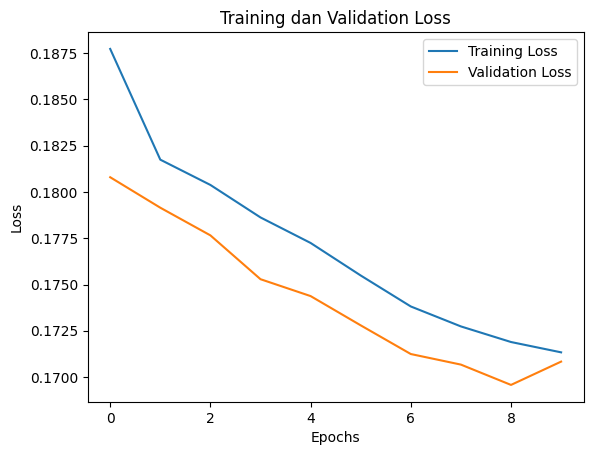

In [19]:
plt.plot(cnnHistory.history['loss'], label='Training Loss')
plt.plot(cnnHistory.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training dan Validation Loss')
plt.show()

### Simpan Prediksi & Perbandingan CNN

In [ ]:
kaggleWorkingPath = Path("/kaggle/working")
outputRootPath = kaggleWorkingPath if kaggleWorkingPath.exists() else Path.cwd()
outputRootPath.mkdir(parents=True, exist_ok=True)

predictionOutputPath = outputRootPath / "prediction_comparison"
predictionOutputPath.mkdir(parents=True, exist_ok=True)

print(f"Folder output prediksi: {predictionOutputPath}")


def buildComparisonDf(dataDf, trueArray, predProbArray, threshold=0.5):
    predArray = (predProbArray >= threshold).astype(int)

    def labelsToText(binaryRow):
        labels = [
            targetLabels[index]
            for index, flag in enumerate(binaryRow)
            if int(flag) == 1
        ]
        return " | ".join(labels) if labels else "No Finding"

    comparisonDf = pd.DataFrame({
        "imageIndex": dataDf["imageIndex"].values,
        "labelSebenarnya": [labelsToText(row) for row in trueArray],
        "labelPrediksi": [labelsToText(row) for row in predArray],
        "jumlahLabelSebenarnya": trueArray.sum(axis=1),
        "jumlahLabelPrediksi": predArray.sum(axis=1),
    })

    comparisonDf["exactMatch"] = (
        comparisonDf["labelSebenarnya"] == comparisonDf["labelPrediksi"]
    ).astype(int)

    return comparisonDf, predArray


def plotTrueVsPredLabelCounts(trueArray, predArray, modelName):
    trueCounts = trueArray.sum(axis=0)
    predCounts = predArray.sum(axis=0)

    plotDf = pd.DataFrame({
        "label": targetLabels,
        "actual": trueCounts,
        "predicted": predCounts,
    }).sort_values("actual", ascending=False)

    plt.figure(figsize=(14, 5))
    xPositions = np.arange(len(plotDf))
    width = 0.4

    plt.bar(xPositions - width / 2, plotDf["actual"], width=width, label="Label Sebenarnya")
    plt.bar(xPositions + width / 2, plotDf["predicted"], width=width, label="Label Prediksi")

    plt.xticks(xPositions, plotDf["label"], rotation=60, ha="right")
    plt.title(f"Perbandingan Distribusi Label - {modelName}")
    plt.ylabel("Jumlah")
    plt.legend()
    plt.tight_layout()
    plt.show()

trueTestArray = testDf[targetLabels].values.astype(int)
cnnPredProb = cnnModel.predict(testDs, verbose=1)

cnnComparisonDf, cnnPredArray = buildComparisonDf(
    dataDf=testDf,
    trueArray=trueTestArray,
    predProbArray=cnnPredProb,
    threshold=0.5
)

cnnComparisonPath = predictionOutputPath / "cnn_label_comparison.csv"
cnnComparisonDf.to_csv(cnnComparisonPath, index=False)

print(f"File comparison CNN tersimpan di: {cnnComparisonPath}")
print(f"Exact match ratio CNN: {cnnComparisonDf['exactMatch'].mean():.4f}")
cnnComparisonDf.head(10)

In [ ]:
plotTrueVsPredLabelCounts(
    trueArray=trueTestArray,
    predArray=cnnPredArray,
    modelName="CNN"
)

# Model Residual Network (ResNet)

In [ ]:
baseModel = keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(imageSize[0], imageSize[1], 3)
)

baseModel.trainable = False

inputs = keras.Input(shape=(imageSize[0], imageSize[1], 3))
x = keras.applications.resnet.preprocess_input(inputs * 255.0)
x = baseModel(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(targetLabels), activation="sigmoid")(x)

resnetModel = keras.Model(inputs, outputs)

resnetModel.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="binaryAccuracy", threshold=0.5),
        keras.metrics.AUC(name="rocAuc"),
        keras.metrics.AUC(name="prAuc", curve="PR"),
        keras.metrics.Precision(name="precision", thresholds=0.5),
        keras.metrics.Recall(name="recall", thresholds=0.5),
    ]
)

resnetModel.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ multiply[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ multiply[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 14)        │     28,686 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,616,398 (90.09 MB)

 Trainable params: 28,686 (112.05 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Training ResNet Tahap 1

In [ ]:
resnetCallbacks = [
    keras.callbacks.ModelCheckpoint("resnetFrozenBest.keras", monitor="val_prAuc", mode="max", save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_prAuc", mode="max", patience=2, restore_best_weights=True)
]

resnetHistory1 = resnetModel.fit(
    trainDs,
    validation_data=validDs,
    epochs=5,
    callbacks=resnetCallbacks
)

Epoch 1/5
2456/2456 ━━━━━━━━━━━━━━━━━━━━ 621s 247ms/step - loss: 0.1849 - prAuc: 0.1494 - precision: 0.2813 - recall: 0.0403 - rocAuc: 0.7508 - val_loss: 0.1710 - val_prAuc: 0.2176 - val_precision: 0.3869 - val_recall: 0.0689 - val_rocAuc: 0.8162
Epoch 2/5
2456/2456 ━━━━━━━━━━━━━━━━━━━━ 627s 255ms/step - loss: 0.1678 - prAuc: 0.1901 - precision: 0.3981 - recall: 0.0434 - rocAuc: 0.7944 - val_loss: 0.1722 - val_prAuc: 0.1986 - val_precision: 0.4685 - val_recall: 0.0152 - val_rocAuc: 0.8056
Epoch 3/5
2456/2456 ━━━━━━━━━━━━━━━━━━━━ 600s 244ms/step - loss: 0.1664 - prAuc: 0.1975 - precision: 0.4006 - recall: 0.0473 - rocAuc: 0.8000 - val_loss: 0.1759 - val_prAuc: 0.1865 - val_precision: 0.3481 - val_recall: 0.0519 - val_rocAuc: 0.8036


## Fine-Tuning ResNet

In [ ]:
baseModel.trainable = True

for layer in baseModel.layers[:-30]:
    layer.trainable = False

resnetModel.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="binaryAccuracy", threshold=0.5),
        keras.metrics.AUC(name="rocAuc"),
        keras.metrics.AUC(name="prAuc", curve="PR"),
        keras.metrics.Precision(name="precision", thresholds=0.5),
        keras.metrics.Recall(name="recall", thresholds=0.5),
    ]
)

resnetHistory2 = resnetModel.fit(
    trainDs,
    validation_data=validDs,
    epochs=10,
    callbacks=[
        keras.callbacks.ModelCheckpoint("resnetFineTuneBest.keras", monitor="val_prAuc", mode="max", save_best_only=True),
        keras.callbacks.EarlyStopping(monitor="val_prAuc", mode="max", patience=3, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_prAuc", mode="max", factor=0.5, patience=2)
    ]
)

Epoch 1/10
2456/2456 ━━━━━━━━━━━━━━━━━━━━ 628s 247ms/step - loss: 0.1648 - prAuc: 0.2018 - precision: 0.4124 - recall: 0.0429 - rocAuc: 0.8016 - val_loss: 0.1605 - val_prAuc: 0.2529 - val_precision: 0.5010 - val_recall: 0.0409 - val_rocAuc: 0.8388 - learning_rate: 1.0000e-05
Epoch 2/10
2456/2456 ━━━━━━━━━━━━━━━━━━━━ 618s 251ms/step - loss: 0.1492 - prAuc: 0.2799 - precision: 0.5548 - recall: 0.0678 - rocAuc: 0.8512 - val_loss: 0.1594 - val_prAuc: 0.2583 - val_precision: 0.4904 - val_recall: 0.0501 - val_rocAuc: 0.8432 - learning_rate: 1.0000e-05
Epoch 3/10
2456/2456 ━━━━━━━━━━━━━━━━━━━━ 613s 249ms/step - loss: 0.1388 - prAuc: 0.3455 - precision: 0.6311 - recall: 0.0998 - rocAuc: 0.8801 - val_loss: 0.1609 - val_prAuc: 0.2563 - val_precision: 0.4597 - val_recall: 0.0742 - val_rocAuc: 0.8413 - learning_rate: 1.0000e-05
Epoch 4/10
2456/2456 ━━━━━━━━━━━━━━━━━━━━ 617s 251ms/step - loss: 0.1266 - prAuc: 0.4269 - precision: 0.6899 - recall: 0.1484 - rocAuc: 0.9092 - val_loss: 0.1667 - val_prAu

## Evaluasi ResNet

In [23]:
resnetEval = resnetModel.evaluate(testDs)
print(resnetEval)

516/516 ━━━━━━━━━━━━━━━━━━━━ 118s 228ms/step - loss: 0.1567 - prAuc: 0.2460 - precision: 0.5069 - recall: 0.0505 - rocAuc: 0.8341
[0.16119565069675446, 0.8393996357917786, 0.26328277587890625, 0.5271828770637512, 0.053822219371795654]


### Training dan Validation Loss

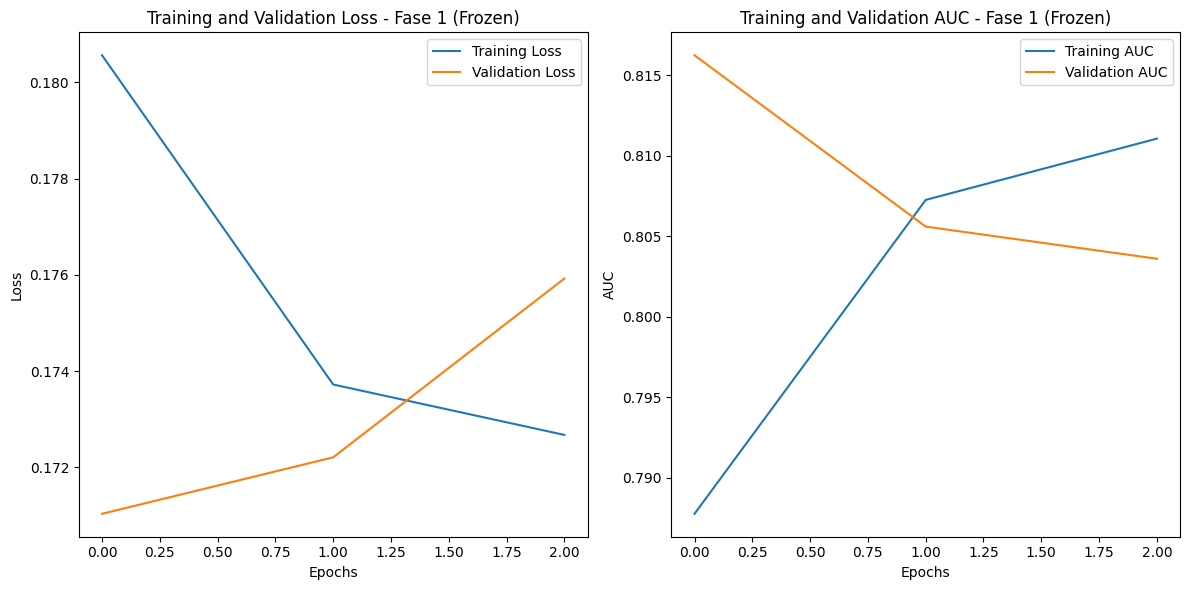

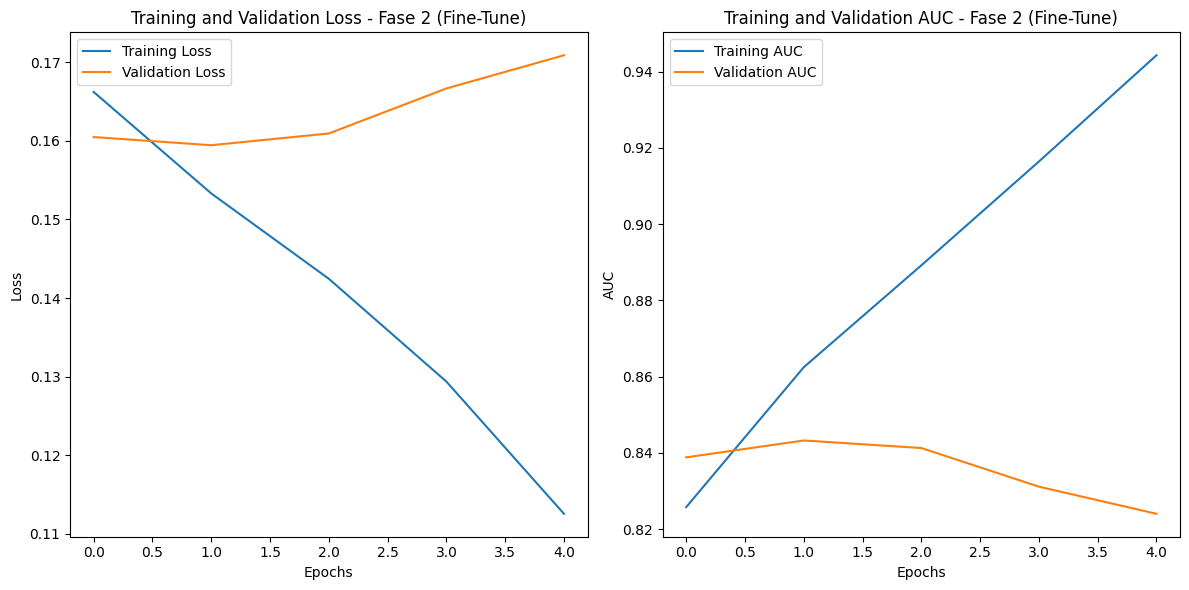

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(resnetHistory1.history['loss'], label='Training Loss')
plt.plot(resnetHistory1.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss - Fase 1 (Frozen)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(resnetHistory1.history['rocAuc'], label='Training AUC')
plt.plot(resnetHistory1.history['val_rocAuc'], label='Validation AUC')
plt.title('Training and Validation AUC - Fase 1 (Frozen)')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(resnetHistory2.history['loss'], label='Training Loss')
plt.plot(resnetHistory2.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss - Fase 2 (Fine-Tune)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(resnetHistory2.history['rocAuc'], label='Training AUC')
plt.plot(resnetHistory2.history['val_rocAuc'], label='Validation AUC')
plt.title('Training and Validation AUC - Fase 2 (Fine-Tune)')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()

### Simpan Prediksi & Perbandingan ResNet

In [ ]:
resnetPredProb = resnetModel.predict(testDs, verbose=1)

resnetComparisonDf, resnetPredArray = buildComparisonDf(
    dataDf=testDf,
    trueArray=trueTestArray,
    predProbArray=resnetPredProb,
    threshold=0.5
)

resnetComparisonPath = predictionOutputPath / "resnet_label_comparison.csv"
resnetComparisonDf.to_csv(resnetComparisonPath, index=False)

print(f"File comparison ResNet tersimpan di: {resnetComparisonPath}")
print(f"Exact match ratio ResNet: {resnetComparisonDf['exactMatch'].mean():.4f}")
resnetComparisonDf.head(10)

In [ ]:
plotTrueVsPredLabelCounts(
    trueArray=trueTestArray,
    predArray=resnetPredArray,
    modelName="ResNet"
)

# Perbandingan CNN vs ResNet

In [ ]:
requiredVars = [
    "cnnModel", "resnetModel", "trainDs", "validDs", "testDs",
    "cnnEval", "resnetEval", "cnnComparisonDf", "resnetComparisonDf"
]

missingVars = [varName for varName in requiredVars if varName not in globals()]
if missingVars:
    print("Variabel belum tersedia:", missingVars)
    print("Jalankan cell training/evaluasi CNN & ResNet terlebih dahulu.")
else:
    print("Semua variabel penting tersedia. Notebook siap lanjut perbandingan.")

In [ ]:
cnnMetricMap = dict(zip(cnnModel.metrics_names, cnnEval))
resnetMetricMap = dict(zip(resnetModel.metrics_names, resnetEval))

comparisonMetrics = ["loss", "binaryAccuracy", "rocAuc", "prAuc", "precision", "recall"]

modelComparisonRows = []
for metricName in comparisonMetrics:
    modelComparisonRows.append({
        "metric": metricName,
        "cnn": cnnMetricMap.get(metricName, np.nan),
        "resnet": resnetMetricMap.get(metricName, np.nan),
    })

modelComparisonDf = pd.DataFrame(modelComparisonRows)

exactMatchCnn = float(cnnComparisonDf["exactMatch"].mean())
exactMatchResnet = float(resnetComparisonDf["exactMatch"].mean())

exactMatchDf = pd.DataFrame([
    {"metric": "exactMatch", "cnn": exactMatchCnn, "resnet": exactMatchResnet}
])

modelComparisonWithExactDf = pd.concat([modelComparisonDf, exactMatchDf], ignore_index=True)

print("Perbandingan metrik CNN vs ResNet:")
display(modelComparisonWithExactDf.round(4))

In [ ]:
plotMetricsDf = modelComparisonWithExactDf[
    modelComparisonWithExactDf["metric"].isin(["rocAuc", "prAuc", "precision", "recall", "exactMatch"])
].copy()

xPositions = np.arange(len(plotMetricsDf))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(xPositions - width / 2, plotMetricsDf["cnn"], width=width, label="CNN")
plt.bar(xPositions + width / 2, plotMetricsDf["resnet"], width=width, label="ResNet")

plt.xticks(xPositions, plotMetricsDf["metric"])
plt.ylim(0, 1)
plt.ylabel("Skor")
plt.title("Perbandingan CNN vs ResNet (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

## Perbandingan Jumlah Benar vs Salah

In [ ]:
totalSamples = len(testDf)

cnnCorrect = int(cnnComparisonDf["exactMatch"].sum())
cnnWrong = int(totalSamples - cnnCorrect)

resnetCorrect = int(resnetComparisonDf["exactMatch"].sum())
resnetWrong = int(totalSamples - resnetCorrect)

correctWrongDf = pd.DataFrame([
    {
        "model": "CNN",
        "benar": cnnCorrect,
        "salah": cnnWrong,
        "persenBenar": cnnCorrect / totalSamples,
        "persenSalah": cnnWrong / totalSamples,
    },
    {
        "model": "ResNet",
        "benar": resnetCorrect,
        "salah": resnetWrong,
        "persenBenar": resnetCorrect / totalSamples,
        "persenSalah": resnetWrong / totalSamples,
    }
])

print("Perbandingan jumlah benar vs salah:")
display(correctWrongDf)

xPositions = np.arange(len(correctWrongDf))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(xPositions - width / 2, correctWrongDf["benar"], width=width, label="Benar")
plt.bar(xPositions + width / 2, correctWrongDf["salah"], width=width, label="Salah")

plt.xticks(xPositions, correctWrongDf["model"])
plt.ylabel("Jumlah Data")
plt.title("Perbandingan Prediksi Benar vs Salah (Exact Match)")
plt.legend()
plt.tight_layout()
plt.show()

# Model You Only Look Once (YOLO)

## Load Bounding Box

In [25]:
bboxDf = pd.read_csv(bboxPath)
bboxDf = bboxDf.iloc[:, :6].copy()
bboxDf.columns = ["imageIndex", "className", "x", "y", "w", "h"]

for columnName in ["x", "y", "w", "h"]:
    bboxDf[columnName] = pd.to_numeric(bboxDf[columnName], errors="coerce")

bboxDf.head()

,imageIndex,className,x,y,w,h
0,00013118_008.png,Atelectasis,225.084746,547.019217,86.779661,79.186441
1,00014716_007.png,Atelectasis,686.101695,131.543498,185.491525,313.491525
2,00029817_009.png,Atelectasis,221.830508,317.053115,155.118644,216.949153
3,00014687_001.png,Atelectasis,726.237288,494.951420,141.016949,55.322034
4,00017877_001.png,Atelectasis,660.067797,569.780787,200.677966,78.101695


## Merge Bounding Box + Image Path + Patient

In [26]:
bboxMergedDf = bboxDf.merge(imagePathDf, on="imageIndex", how="left")
bboxMergedDf = bboxMergedDf.merge(
    labelDf[["imageIndex", "patientId", "originalImageWidth", "originalImageHeight"]],
    on="imageIndex",
    how="left"
)

bboxMergedDf = bboxMergedDf.dropna(subset=["imagePath"]).reset_index(drop=True)

print(bboxMergedDf.shape)
bboxMergedDf.head()

(984, 10)


,imageIndex,className,x,y,w,h,imagePath,patientId,originalImageWidth,originalImageHeight
0,00013118_008.png,Atelectasis,225.084746,547.019217,86.779661,79.186441,/kaggle/input/datasets/organizations/nih-chest...,13118,2992,2991
1,00014716_007.png,Atelectasis,686.101695,131.543498,185.491525,313.491525,/kaggle/input/datasets/organizations/nih-chest...,14716,3056,2544
2,00029817_009.png,Atelectasis,221.830508,317.053115,155.118644,216.949153,/kaggle/input/datasets/organizations/nih-chest...,29817,3056,2544
3,00014687_001.png,Atelectasis,726.237288,494.951420,141.016949,55.322034,/kaggle/input/datasets/organizations/nih-chest...,14687,2500,2048
4,00017877_001.png,Atelectasis,660.067797,569.780787,200.677966,78.101695,/kaggle/input/datasets/organizations/nih-chest...,17877,2500,2048


## Split YOLO Data

In [27]:
bboxPatientIds = bboxMergedDf["patientId"].dropna().unique()

trainPatientsYolo, tempPatientsYolo = train_test_split(
    bboxPatientIds,
    test_size=0.30,
    random_state=42
)

validPatientsYolo, testPatientsYolo = train_test_split(
    tempPatientsYolo,
    test_size=0.50,
    random_state=42
)

trainBboxDf = bboxMergedDf[bboxMergedDf["patientId"].isin(trainPatientsYolo)].reset_index(drop=True)
validBboxDf = bboxMergedDf[bboxMergedDf["patientId"].isin(validPatientsYolo)].reset_index(drop=True)
testBboxDf = bboxMergedDf[bboxMergedDf["patientId"].isin(testPatientsYolo)].reset_index(drop=True)

print(trainBboxDf.shape, validBboxDf.shape, testBboxDf.shape)

(684, 10) (160, 10) (140, 10)


## Mapping Class YOLO

In [28]:
classNames = sorted(bboxMergedDf["className"].dropna().unique().tolist())
classToId = {name: index for index, name in enumerate(classNames)}

print(classToId)

{'Atelectasis': 0, 'Cardiomegaly': 1, 'Effusion': 2, 'Infiltrate': 3, 'Mass': 4, 'Nodule': 5, 'Pneumonia': 6, 'Pneumothorax': 7}


## Buat Folder YOLO

In [29]:
yoloRootPath = Path("/kaggle/working/nihYOLO")

for splitName in ["train", "val", "test"]:
    (yoloRootPath / "images" / splitName).mkdir(parents=True, exist_ok=True)
    (yoloRootPath / "labels" / splitName).mkdir(parents=True, exist_ok=True)

## Konversi ke Format YOLO

In [ ]:
def writeYoloSplit(splitDf, splitName):
    groupedDf = splitDf.groupby("imageIndex")

    for imageIndex, groupDf in groupedDf:
        imagePath = groupDf["imagePath"].iloc[0]
        imageWidth = float(groupDf["originalImageWidth"].iloc[0])
        imageHeight = float(groupDf["originalImageHeight"].iloc[0])

        outputImagePath = yoloRootPath / "images" / splitName / imageIndex
        outputLabelPath = yoloRootPath / "labels" / splitName / (Path(imageIndex).stem + ".txt")

        shutil.copy(imagePath, outputImagePath)

        yoloLines = []
        for _, row in groupDf.iterrows():
            classId = classToId[row["className"]]

            x = float(row["x"])
            y = float(row["y"])
            w = float(row["w"])
            h = float(row["h"])

            xCenter = (x + w / 2.0) / imageWidth
            yCenter = (y + h / 2.0) / imageHeight
            widthNorm = w / imageWidth
            heightNorm = h / imageHeight

            yoloLines.append(
                f"{classId} {xCenter:.6f} {yCenter:.6f} {widthNorm:.6f} {heightNorm:.6f}"
            )

        outputLabelPath.write_text("\n".join(yoloLines))

writeYoloSplit(trainBboxDf, "train")
writeYoloSplit(validBboxDf, "val")
writeYoloSplit(testBboxDf, "test")

## Buat data.yaml

In [ ]:
dataYamlPath = yoloRootPath / "data.yaml"

yamlText = f"""path: {str(yoloRootPath)}
train: images/train
val: images/val
test: images/test

names:
"""

for index, className in enumerate(classNames):
    yamlText += f"  {index}: {className}\n"

dataYamlPath.write_text(yamlText)
print(yamlText)

path: /kaggle/working/nihYOLO
train: images/train
val: images/val
test: images/test

names:
  0: Atelectasis
  1: Cardiomegaly
  2: Effusion
  3: Infiltrate
  4: Mass
  5: Nodule
  6: Pneumonia
  7: Pneumothorax



## Install dan Train YOLO

In [ ]:
!pip -q install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.9 MB/s eta 0:00:00


In [33]:
%%capture --no-stdout --no-display
from ultralytics import YOLO

yoloModel = YOLO("yolov8n.pt")

yoloModel.train(
    data=str(dataYamlPath),
    imgsz=640,
    epochs=50,
    batch=16,
    device=0
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/nihYOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, in

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bfb00cada90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,

## Evaluasi YOLO

In [ ]:
import json

yoloMetrics = yoloModel.val(data=str(dataYamlPath), verbose=False)

outputBasePath = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
yoloEvalPath = outputBasePath / "yolo_evaluation"
yoloEvalPath.mkdir(parents=True, exist_ok=True)

jsonPath = yoloEvalPath / "yolo_metrics.json"
csvPath = yoloEvalPath / "yolo_metrics.csv"
rawTextPath = yoloEvalPath / "yolo_metrics_raw.txt"

rawTextPath.write_text(str(yoloMetrics))

if hasattr(yoloMetrics, "results_dict"):
    metricDict = {
        key: float(value) if isinstance(value, (int, float, np.integer, np.floating)) else str(value)
        for key, value in yoloMetrics.results_dict.items()
    }
else:
    metricDict = {"message": "results_dict tidak tersedia", "raw_repr": str(yoloMetrics)}

jsonPath.write_text(json.dumps(metricDict, indent=2))
pd.DataFrame([metricDict]).to_csv(csvPath, index=False)

print(f"Metrik YOLO disimpan di: {jsonPath}")
print(f"Ringkasan CSV disimpan di: {csvPath}")
print(f"Raw hasil evaluasi disimpan di: {rawTextPath}")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3855.5±664.2 MB/s, size: 417.9 KB)
val: Scanning /kaggle/working/nihYOLO/labels/val.cache... 143 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 143/143 60.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.9it/s 3.1s
                   all        143        160      0.757     0.0272    0.00754     0.0028
           Atelectasis         35         35          1          0    0.00253   0.000725
          Cardiomegaly         23         23     0.0527      0.217     0.0486     0.0193
              Effusion         29         29          1          0    0.00678    0.00169
            Infiltrate         18         18          1          0    0.00135   0.000452
                  Mass         15         15  

### Menyimpan Model YOLO

In [35]:
yoloModel.save("/kaggle/working/YOLOTrainedModel.pt")
print("Model YOLO telah disimpan.")

Model YOLO telah disimpan.
